# **Classification Models Implementation**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, log_loss
)


In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")


In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [4]:
print("Classes:", dict(enumerate(data.target_names)))
print("\nClass distribution:")
print(y.value_counts())

Classes: {0: np.str_('malignant'), 1: np.str_('benign')}

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


**Data Splitting**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [6]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (455, 30)
Testing : (114, 30)


In [7]:
results = []

def evaluate_model(name, model, X_eval, y_eval, y_pred=None, y_prob=None, cv_scores=None):
    if y_pred is None:
        y_pred = model.predict(X_eval)

    if y_prob is None and hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred),
        "Recall": recall_score(y_eval, y_pred),
        "F1": f1_score(y_eval, y_pred),
        "ROC-AUC": roc_auc_score(y_eval, y_prob) if y_prob is not None else np.nan,
        "Log Loss": log_loss(y_eval, y_prob) if y_prob is not None else np.nan
    }

    if cv_scores is not None:
        row["CV Mean Accuracy"] = np.mean(cv_scores)
        row["CV Std"] = np.std(cv_scores)

    results.append(row)

    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print(pd.Series(row).round(4))
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, target_names=data.target_names))

    return row


## **Logistic Regression**

In [8]:
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

In [9]:
logistic = LogisticRegression(
    solver="lbfgs",
    max_iter=2000,
    C=1.0,
    random_state=42
)

logistic.fit(X_train_lr, y_train)

y_pred_lr = logistic.predict(X_test_lr)
y_prob_lr = logistic.predict_proba(X_test_lr)[:, 1]


In [10]:
# Explicit test-set log loss / cost
lr_log_loss = log_loss(y_test, y_prob_lr)

In [11]:

# Cross-validation
lr_cv = cross_val_score(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(solver="lbfgs", max_iter=2000, C=1.0))
    ]),
    X_train, y_train, cv=5, scoring="accuracy"
)

In [12]:
print("Log Loss / Cost:", round(lr_log_loss, 6))
print("5-Fold CV Accuracy:", np.round(lr_cv, 4))
print("Coefficients shape:", logistic.coef_.shape)

Log Loss / Cost: 0.077746
5-Fold CV Accuracy: [0.967 0.978 0.967 1.    0.989]
Coefficients shape: (1, 30)


In [13]:
evaluate_model(
    "Logistic Regression",
    logistic,
    X_test_lr,
    y_test,
    y_pred_lr,
    y_prob_lr,
    lr_cv
)


Logistic Regression
Model               Logistic Regression
Accuracy                       0.982456
Precision                      0.986111
Recall                         0.986111
F1                             0.986111
ROC-AUC                         0.99537
Log Loss                       0.077746
CV Mean Accuracy                0.98022
CV Std                         0.012815
dtype: object

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



{'Model': 'Logistic Regression',
 'Accuracy': 0.9824561403508771,
 'Precision': 0.9861111111111112,
 'Recall': 0.9861111111111112,
 'F1': 0.9861111111111112,
 'ROC-AUC': np.float64(0.9953703703703703),
 'Log Loss': 0.07774649384096737,
 'CV Mean Accuracy': np.float64(0.9802197802197803),
 'CV Std': np.float64(0.012815278889769896)}

## K-Nearest Neighbors

In [14]:
scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(X_train)
X_test_knn = scaler_knn.transform(X_test)

In [15]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_grid = GridSearchCV(
    knn_pipe,
    {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)


In [16]:

knn_grid.fit(X_train, y_train)

knn = knn_grid.best_estimator_
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1]

In [17]:
print("Best Parameters:", knn_grid.best_params_)
print("Best CV Accuracy:", round(knn_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_knn), 6))

evaluate_model(
    "KNN",
    knn,
    X_test,
    y_test,
    y_pred_knn,
    y_prob_knn,
    knn_grid.cv_results_["mean_test_score"]
)

Best Parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 7, 'model__weights': 'uniform'}
Best CV Accuracy: 0.971429
Test Log Loss: 0.107417

KNN
Model                    KNN
Accuracy            0.973684
Precision               0.96
Recall                   1.0
F1                  0.979592
ROC-AUC             0.988426
Log Loss            0.107417
CV Mean Accuracy    0.965228
CV Std              0.004278
dtype: object

Confusion Matrix:
[[39  3]
 [ 0 72]]

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



{'Model': 'KNN',
 'Accuracy': 0.9736842105263158,
 'Precision': 0.96,
 'Recall': 1.0,
 'F1': 0.9795918367346939,
 'ROC-AUC': np.float64(0.9884259259259259),
 'Log Loss': 0.1074174118109876,
 'CV Mean Accuracy': np.float64(0.9652276295133438),
 'CV Std': np.float64(0.004278405047068058)}

## Gaussian Naive Bayes

In [18]:
scaler_nb = StandardScaler()
X_train_nb = scaler_nb.fit_transform(X_train)
X_test_nb = scaler_nb.transform(X_test)

nb = GaussianNB()
nb.fit(X_train_nb, y_train)

y_pred_nb = nb.predict(X_test_nb)
y_prob_nb = nb.predict_proba(X_test_nb)[:, 1]


In [19]:
nb_nll = log_loss(y_test, y_prob_nb)

nb_cv = cross_val_score(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),
    X_train, y_train, cv=5, scoring="accuracy"
)

In [21]:
print("Negative Log-Likelihood:", round(nb_nll, 6))
print("5-Fold CV Accuracy:", np.round(nb_cv, 4))

evaluate_model(
    "Gaussian Naive Bayes",
    nb,
    X_test_nb,
    y_test,
    y_pred_nb,
    y_prob_nb,
    nb_cv
)

Negative Log-Likelihood: 0.436964
5-Fold CV Accuracy: [0.9341 0.9341 0.9341 0.9341 0.9231]

Gaussian Naive Bayes
Model               Gaussian Naive Bayes
Accuracy                        0.929825
Precision                       0.944444
Recall                          0.944444
F1                              0.944444
ROC-AUC                         0.986772
Log Loss                        0.436964
CV Mean Accuracy                0.931868
CV Std                          0.004396
dtype: object

Confusion Matrix:
[[38  4]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



{'Model': 'Gaussian Naive Bayes',
 'Accuracy': 0.9298245614035088,
 'Precision': 0.9444444444444444,
 'Recall': 0.9444444444444444,
 'F1': 0.9444444444444444,
 'ROC-AUC': np.float64(0.9867724867724867),
 'Log Loss': 0.43696415437273667,
 'CV Mean Accuracy': np.float64(0.9318681318681319),
 'CV Std': np.float64(0.00439560439560438)}

## **Support Vector Machine**

In [22]:
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_grid = GridSearchCV(
    svm_pipe,
    {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.001, 0.01, 0.1]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

svm = svm_grid.best_estimator_
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Accuracy:", round(svm_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_svm), 6))

evaluate_model(
    "SVM",
    svm,
    X_test,
    y_test,
    y_pred_svm,
    y_prob_svm,
    svm_grid.cv_results_["mean_test_score"]
)


Best Parameters: {'model__C': 10, 'model__gamma': 0.01}
Best CV Accuracy: 0.98022
Test Log Loss: 0.076724

SVM
Model                    SVM
Accuracy            0.982456
Precision           0.986111
Recall              0.986111
F1                  0.986111
ROC-AUC             0.997685
Log Loss            0.076724
CV Mean Accuracy    0.882637
CV Std              0.137491
dtype: object

Confusion Matrix:
[[41  1]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



{'Model': 'SVM',
 'Accuracy': 0.9824561403508771,
 'Precision': 0.9861111111111112,
 'Recall': 0.9861111111111112,
 'F1': 0.9861111111111112,
 'ROC-AUC': np.float64(0.9976851851851851),
 'Log Loss': 0.07672354971112029,
 'CV Mean Accuracy': np.float64(0.8826373626373627),
 'CV Std': np.float64(0.13749075344083783)}

## **Decision Tree**

In [23]:
tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        "criterion": ["gini", "entropy", "log_loss"],
        "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

tree = tree_grid.best_estimator_
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

print("Best Parameters:", tree_grid.best_params_)
print("Best CV Accuracy:", round(tree_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_tree), 6))
print("Tree Depth:", tree.get_depth())
print("Number of Leaves:", tree.get_n_leaves())

evaluate_model(
    "Decision Tree",
    tree,
    X_test,
    y_test,
    y_pred_tree,
    y_prob_tree,
    tree_grid.cv_results_["mean_test_score"]
)


Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 0.938462
Test Log Loss: 1.655946
Tree Depth: 4
Number of Leaves: 11

Decision Tree
Model               Decision Tree
Accuracy                 0.938596
Precision                0.957746
Recall                   0.944444
F1                       0.951049
ROC-AUC                  0.934193
Log Loss                 1.655946
CV Mean Accuracy         0.924217
CV Std                   0.006169
dtype: object

Confusion Matrix:
[[39  3]
 [ 4 68]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



{'Model': 'Decision Tree',
 'Accuracy': 0.9385964912280702,
 'Precision': 0.9577464788732394,
 'Recall': 0.9444444444444444,
 'F1': 0.951048951048951,
 'ROC-AUC': np.float64(0.9341931216931217),
 'Log Loss': 1.655945574536771,
 'CV Mean Accuracy': np.float64(0.9242165242165243),
 'CV Std': np.float64(0.00616924552592476)}

## **Random Forest**

In [24]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    {
        "n_estimators": [100, 200],
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5],
        "max_features": ["sqrt", "log2"]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Accuracy:", round(rf_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_rf), 6))
print("Number of Trees:", rf.n_estimators)

evaluate_model(
    "Random Forest",
    rf,
    X_test,
    y_test,
    y_pred_rf,
    y_prob_rf,
    rf_grid.cv_results_["mean_test_score"]
)


Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.967033
Test Log Loss: 0.113308
Number of Trees: 100

Random Forest
Model               Random Forest
Accuracy                 0.947368
Precision                0.958333
Recall                   0.958333
F1                       0.958333
ROC-AUC                  0.993056
Log Loss                 0.113308
CV Mean Accuracy         0.957761
CV Std                   0.004686
dtype: object

Confusion Matrix:
[[39  3]
 [ 3 69]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



{'Model': 'Random Forest',
 'Accuracy': 0.9473684210526315,
 'Precision': 0.9583333333333334,
 'Recall': 0.9583333333333334,
 'F1': 0.9583333333333334,
 'ROC-AUC': np.float64(0.9930555555555556),
 'Log Loss': 0.11330845961999433,
 'CV Mean Accuracy': np.float64(0.957760989010989),
 'CV Std': np.float64(0.004685958819619707)}

## **Gradient Boosting**

In [25]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {
        "n_estimators": [50, 100, 150],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [1, 2, 3],
        "subsample": [0.8, 1.0]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

gb = gb_grid.best_estimator_
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("Best Parameters:", gb_grid.best_params_)
print("Best CV Accuracy:", round(gb_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_gb), 6))
print("Number of Boosting Stages:", gb.n_estimators)

evaluate_model(
    "Gradient Boosting",
    gb,
    X_test,
    y_test,
    y_pred_gb,
    y_prob_gb,
    gb_grid.cv_results_["mean_test_score"]
)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 150, 'subsample': 0.8}
Best CV Accuracy: 0.975824
Test Log Loss: 0.103928
Number of Boosting Stages: 150

Gradient Boosting
Model               Gradient Boosting
Accuracy                     0.938596
Precision                    0.945205
Recall                       0.958333
F1                           0.951724
ROC-AUC                      0.991733
Log Loss                     0.103928
CV Mean Accuracy             0.955922
CV Std                       0.009193
dtype: object

Confusion Matrix:
[[38  4]
 [ 3 69]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



{'Model': 'Gradient Boosting',
 'Accuracy': 0.9385964912280702,
 'Precision': 0.9452054794520548,
 'Recall': 0.9583333333333334,
 'F1': 0.9517241379310345,
 'ROC-AUC': np.float64(0.9917328042328042),
 'Log Loss': 0.10392833662967109,
 'CV Mean Accuracy': np.float64(0.955921855921856),
 'CV Std': np.float64(0.009193255425680662)}

## **AdaBoost**

In [26]:
ada_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    {
        "n_estimators": [50, 100, 150, 200],
        "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)

ada = ada_grid.best_estimator_
y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

print("Best Parameters:", ada_grid.best_params_)
print("Best CV Accuracy:", round(ada_grid.best_score_, 6))
print("Test Log Loss:", round(log_loss(y_test, y_prob_ada), 6))
print("Number of Estimators:", ada.n_estimators)

evaluate_model(
    "AdaBoost",
    ada,
    X_test,
    y_test,
    y_pred_ada,
    y_prob_ada,
    ada_grid.cv_results_["mean_test_score"]
)


Best Parameters: {'learning_rate': 0.5, 'n_estimators': 100}
Best CV Accuracy: 0.978022
Test Log Loss: 0.38289
Number of Estimators: 100

AdaBoost
Model               AdaBoost
Accuracy             0.95614
Precision           0.946667
Recall              0.986111
F1                  0.965986
ROC-AUC             0.983466
Log Loss             0.38289
CV Mean Accuracy     0.96022
CV Std              0.015477
dtype: object

Confusion Matrix:
[[38  4]
 [ 1 71]]

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



{'Model': 'AdaBoost',
 'Accuracy': 0.956140350877193,
 'Precision': 0.9466666666666667,
 'Recall': 0.9861111111111112,
 'F1': 0.9659863945578231,
 'ROC-AUC': np.float64(0.9834656084656085),
 'Log Loss': 0.38289042845567656,
 'CV Mean Accuracy': np.float64(0.9602197802197802),
 'CV Std': np.float64(0.01547695990457873)}

## **Final Model Comparison**

In [27]:
# Final comparison
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

print(results_df.round(4).to_string(index=False))


               Model  Accuracy  Precision  Recall     F1  ROC-AUC  Log Loss  CV Mean Accuracy  CV Std
 Logistic Regression    0.9825     0.9861  0.9861 0.9861   0.9954    0.0777            0.9802  0.0128
                 SVM    0.9825     0.9861  0.9861 0.9861   0.9977    0.0767            0.8826  0.1375
                 KNN    0.9737     0.9600  1.0000 0.9796   0.9884    0.1074            0.9652  0.0043
            AdaBoost    0.9561     0.9467  0.9861 0.9660   0.9835    0.3829            0.9602  0.0155
       Random Forest    0.9474     0.9583  0.9583 0.9583   0.9931    0.1133            0.9578  0.0047
   Gradient Boosting    0.9386     0.9452  0.9583 0.9517   0.9917    0.1039            0.9559  0.0092
       Decision Tree    0.9386     0.9577  0.9444 0.9510   0.9342    1.6559            0.9242  0.0062
Gaussian Naive Bayes    0.9298     0.9444  0.9444 0.9444   0.9868    0.4370            0.9319  0.0044
Gaussian Naive Bayes    0.9298     0.9444  0.9444 0.9444   0.9868    0.4370       

In [28]:
# Rank models by major evaluation metrics
metric_ranks = results_df.copy()

for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    metric_ranks[f"{metric} Rank"] = metric_ranks[metric].rank(
        ascending=False,
        method="min"
    )

metric_ranks["Log Loss Rank"] = metric_ranks["Log Loss"].rank(
    ascending=True,
    method="min"
)

display(metric_ranks.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Log Loss,CV Mean Accuracy,CV Std,Accuracy Rank,Precision Rank,Recall Rank,F1 Rank,ROC-AUC Rank,Log Loss Rank
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954,0.0777,0.9802,0.0128,1.0,1.0,2.0,1.0,2.0,2.0
1,SVM,0.9825,0.9861,0.9861,0.9861,0.9977,0.0767,0.8826,0.1375,1.0,1.0,2.0,1.0,1.0,1.0
2,KNN,0.9737,0.9600,1.0000,0.9796,0.9884,0.1074,0.9652,0.0043,3.0,3.0,1.0,3.0,5.0,4.0
3,AdaBoost,0.9561,0.9467,0.9861,0.9660,0.9835,0.3829,0.9602,0.0155,4.0,6.0,2.0,4.0,8.0,6.0
4,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9931,0.1133,0.9578,0.0047,5.0,4.0,5.0,5.0,3.0,5.0
5,Gradient Boosting,0.9386,0.9452,0.9583,0.9517,0.9917,0.1039,0.9559,0.0092,6.0,7.0,5.0,6.0,4.0,3.0
6,Decision Tree,0.9386,0.9577,0.9444,0.9510,0.9342,1.6559,0.9242,0.0062,6.0,5.0,7.0,7.0,9.0,9.0
7,Gaussian Naive Bayes,0.9298,0.9444,0.9444,0.9444,0.9868,0.4370,0.9319,0.0044,8.0,8.0,7.0,8.0,6.0,7.0
8,Gaussian Naive Bayes,0.9298,0.9444,0.9444,0.9444,0.9868,0.4370,0.9319,0.0044,8.0,8.0,7.0,8.0,6.0,7.0


## **ROC Curves**

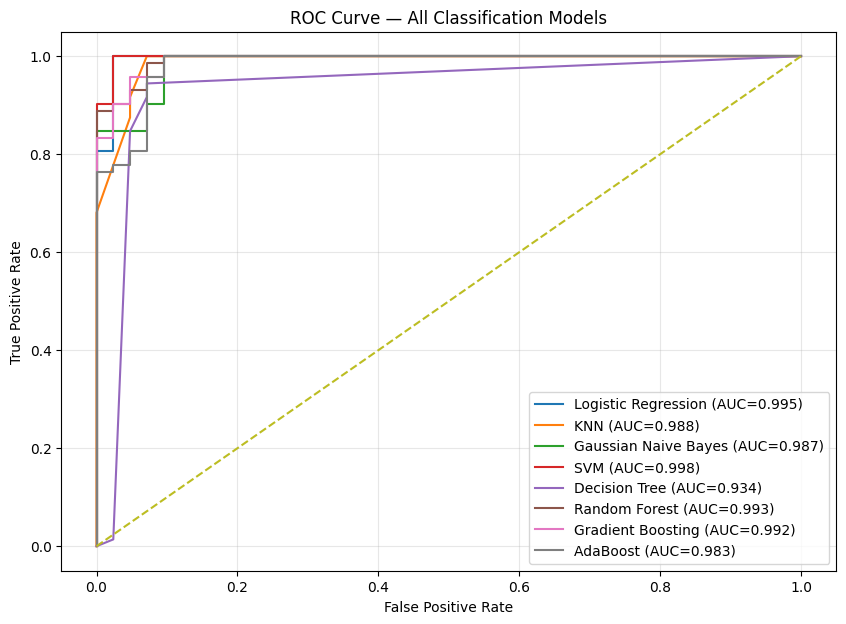

In [29]:
# ROC curves for all models
model_probabilities = {
    "Logistic Regression": y_prob_lr,
    "KNN": y_prob_knn,
    "Gaussian Naive Bayes": y_prob_nb,
    "SVM": y_prob_svm,
    "Decision Tree": y_prob_tree,
    "Random Forest": y_prob_rf,
    "Gradient Boosting": y_prob_gb,
    "AdaBoost": y_prob_ada
}

plt.figure(figsize=(10, 7))

for name, y_prob in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Classification Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## **Confusion Matrices**

In [30]:
# Confusion matrices
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Gaussian Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "AdaBoost": y_pred_ada
}

for name, y_pred in model_predictions.items():
    print(f"\n{name}")
    print(confusion_matrix(y_test, y_pred))



Logistic Regression
[[41  1]
 [ 1 71]]

KNN
[[39  3]
 [ 0 72]]

Gaussian Naive Bayes
[[38  4]
 [ 4 68]]

SVM
[[41  1]
 [ 1 71]]

Decision Tree
[[39  3]
 [ 4 68]]

Random Forest
[[39  3]
 [ 3 69]]

Gradient Boosting
[[38  4]
 [ 3 69]]

AdaBoost
[[38  4]
 [ 1 71]]


## **Best Model**

In [31]:
# Select best model by F1 score
best_row = results_df.iloc[0]

print("Best model by F1 score:")
print(best_row.round(4))

print("\nFull evaluation:")
print(results_df.round(4).to_string(index=False))


Best model by F1 score:
Model               Logistic Regression
Accuracy                       0.982456
Precision                      0.986111
Recall                         0.986111
F1                             0.986111
ROC-AUC                         0.99537
Log Loss                       0.077746
CV Mean Accuracy                0.98022
CV Std                         0.012815
Name: 0, dtype: object

Full evaluation:
               Model  Accuracy  Precision  Recall     F1  ROC-AUC  Log Loss  CV Mean Accuracy  CV Std
 Logistic Regression    0.9825     0.9861  0.9861 0.9861   0.9954    0.0777            0.9802  0.0128
                 SVM    0.9825     0.9861  0.9861 0.9861   0.9977    0.0767            0.8826  0.1375
                 KNN    0.9737     0.9600  1.0000 0.9796   0.9884    0.1074            0.9652  0.0043
            AdaBoost    0.9561     0.9467  0.9861 0.9660   0.9835    0.3829            0.9602  0.0155
       Random Forest    0.9474     0.9583  0.9583 0.9583   0.9931

Logistic Regression is the safest choice from this experiment because it combines extremely high test performance with the best CV accuracy and relatively low CV variation.

However, if the priority is ranking/separating the classes, SVM has the highest ROC-AUC (99.77%).

And if the priority is not missing positive cases, KNN's 100% recall is particularly interesting.

**Note!!**

the SVM CV result (88.26% ± 13.75%) is suspiciously unstable compared with its excellent test score. I would investigate the cross-validation setup/results before declaring SVM inferior in generalization. Also, the duplicated Gaussian Naive Bayes row should be removed from the notebook's final comparison if it is genuinely duplicated.